

![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)

<div style="float: right; font-size: small;">
    Erstellt von Fakher Ahmed für Data Science Institut by Fabian Rappert
</div>

# Boxplot – Einführung

Ein Boxplot oder Kastendiagramm veranschaulicht die Verteilung numerischer Daten anhand von:
- **Box (Kasten)**: Zeigt den Bereich zwischen dem ersten (Q1) und dem dritten (Q3) Quartil.
- **Median**: Eine Linie innerhalb der Box stellt den Median (Q2) dar.
- **Whisker (Antennen)**: Verlaufen in vielen Implementierungen von Q1 - 1.5 * IQR bis Q3 + 1.5 * IQR (IQR = Q3 - Q1).
  - Werte außerhalb dieses Bereichs werden als **Ausreißer** gekennzeichnet (Punkte oder Kreise).

Je **schmaler** die Box, desto **geringer** ist die Streuung zwischen Q1 und Q3.  
Mit einem Blick kannst du also erkennen, wo der **Großteil** der Daten liegt, ob **Ausreißer** vorhanden sind und ob die Verteilung **asymmetrisch** ist.


Auch hier gilt wieder: den Code der Visualisierungen brauchst du erstmal nicht zu verstehen.

---

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Beispiel-Datensätze erstellen
np.random.seed(42)
data1 = np.random.normal(loc=50, scale=10, size=1000)  # Normalverteilung, Mittelwert 50, Std 10
data2 = np.random.exponential(scale=20, size=1000)  # Exponentialverteilung, Skalenparameter 20
data3 = np.random.uniform(low=30, high=70, size=1000)  # Gleichverteilung

# Mehrere Datensätze in einer Liste
data = [data1, data2, data3]

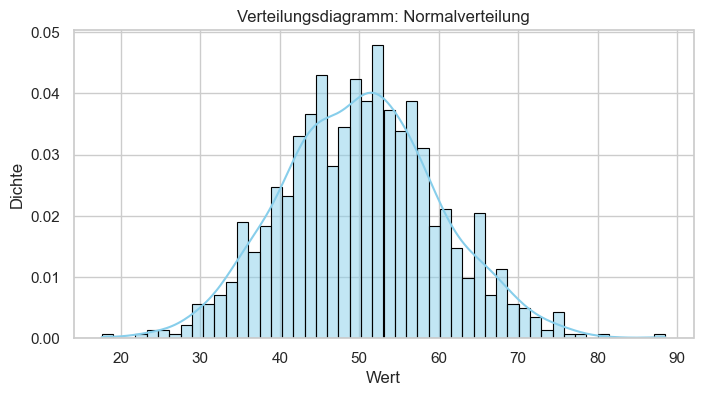

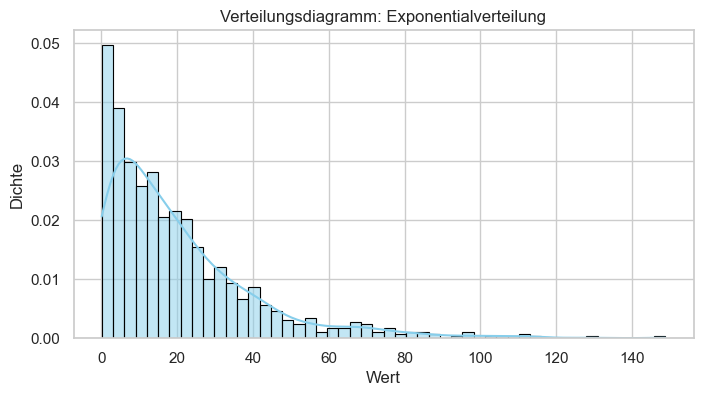

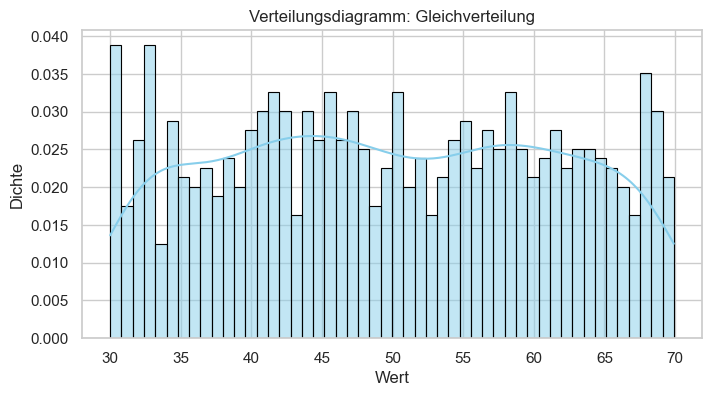

In [4]:
# Verteilungsdiagramme (Histogramm + Dichtekurve) für alle 3 Datensätze

import seaborn as sns

# Stil setzen
sns.set(style="whitegrid")

# Namen und Daten zusammenführen
datasets = {"Normalverteilung": data1, "Exponentialverteilung": data2, "Gleichverteilung": data3}

# Plotten
for name, values in datasets.items():
    plt.figure(figsize=(8, 4))

    # Histogramm + KDE (Kernel Density Estimation)
    sns.histplot(values, kde=True, stat="density", bins=50, color="skyblue", edgecolor="black")

    plt.title(f"Verteilungsdiagramm: {name}")
    plt.xlabel("Wert")
    plt.ylabel("Dichte")
    plt.show()

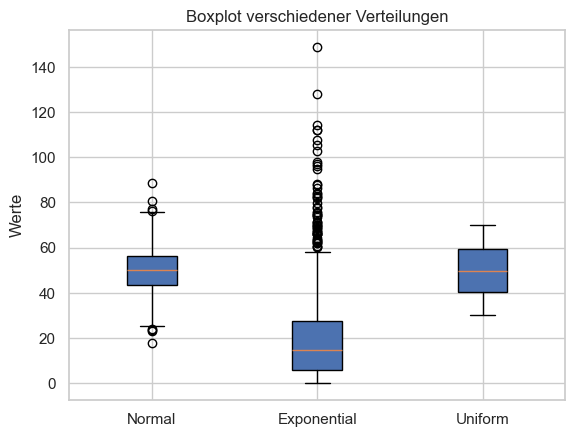

In [5]:
plt.figure()
plt.boxplot(data, vert=True, patch_artist=True, tick_labels=["Normal", "Exponential", "Uniform"])

plt.title("Boxplot verschiedener Verteilungen")
plt.ylabel("Werte")
plt.show()

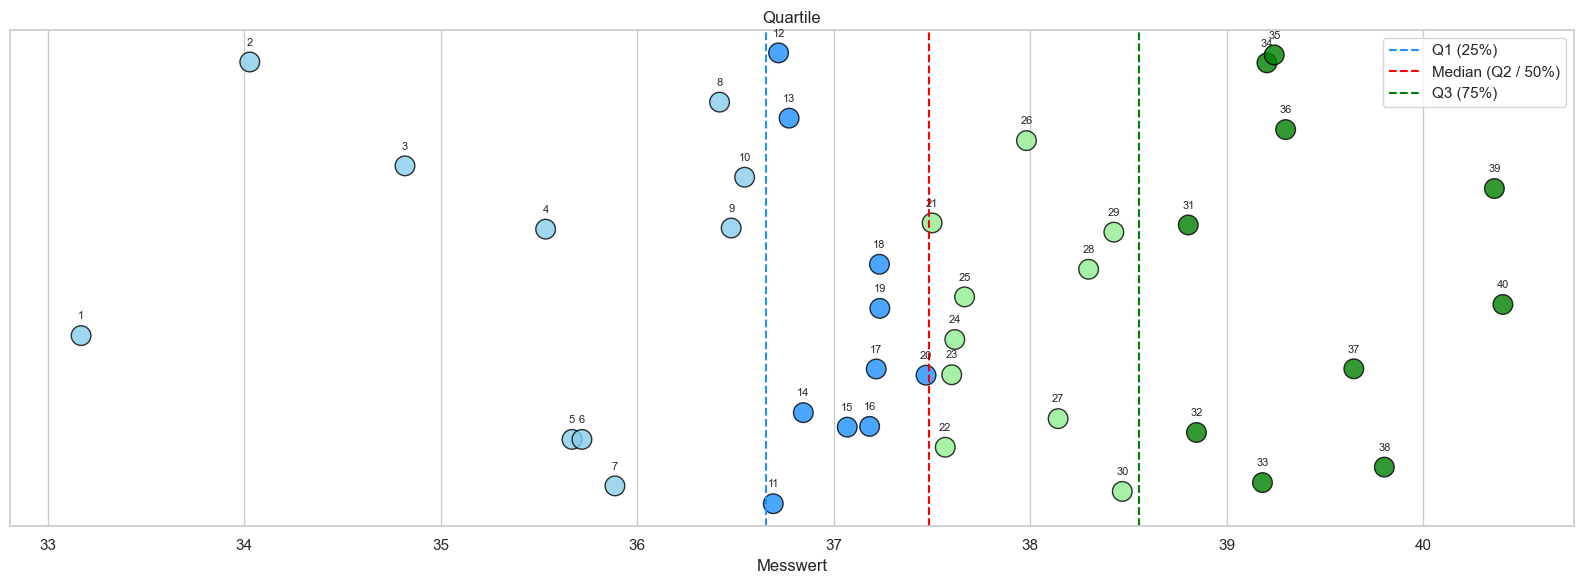

In [6]:
### Der folgende Code muss an dieser Stelle nicht gelernt/nachvollzogen werden. Es geht hier nur um das Ergebnis (Plot).

import matplotlib.pyplot as plt
import numpy as np

# Beispiel-Daten
np.random.seed(0)
daten = np.random.normal(loc=37, scale=1.5, size=40)
daten.sort()

# Quartile berechnen
q1 = np.percentile(daten, 25)
q2 = np.percentile(daten, 50)
q3 = np.percentile(daten, 75)

# Farben je Quartil
farben = []
for wert in daten:
    if wert <= q1:
        farben.append("skyblue")
    elif wert <= q2:
        farben.append("dodgerblue")
    elif wert <= q3:
        farben.append("lightgreen")
    else:
        farben.append("green")

# Leichtes vertikales Jittern, identisch für Punkt & Zahl
np.random.seed(42)
jitter = np.random.uniform(0, 0.1, size=len(daten))
y = 1 + jitter

# Plot
plt.figure(figsize=(16, 6))
plt.scatter(daten, y, c=farben, s=200, alpha=0.8, edgecolor="black")

# Nummerierung – folgt exakt dem Jitter
for i, (x, y_val) in enumerate(zip(daten, y)):
    plt.text(x, y_val + 0.003, str(i + 1), ha="center", va="bottom", fontsize=8)

# Quartil-Grenzen einzeichnen
plt.axvline(q1, color="dodgerblue", linestyle="--", label="Q1 (25%)")
plt.axvline(q2, color="red", linestyle="--", label="Median (Q2 / 50%)")
plt.axvline(q3, color="green", linestyle="--", label="Q3 (75%)")

plt.title("Quartile")
plt.xlabel("Messwert")
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

Erstes Quartil (Q1)       : 36.66
Median (Q2)              : 37.49
Drittes Quartil (Q3)     : 38.55
IQR (Q3 - Q1)            : 1.90
Unteres Ende (Whisker)   : 33.81
Oberes Ende (Whisker)    : 41.40


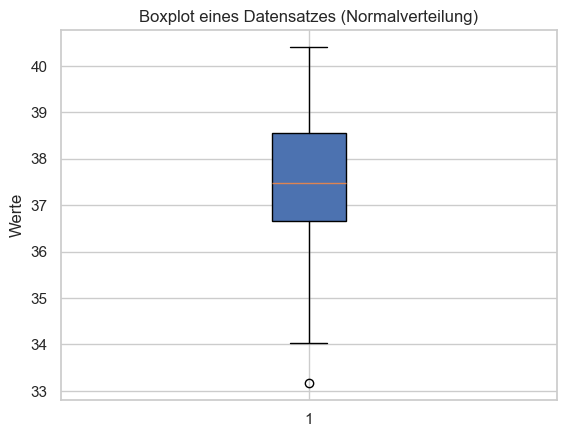

In [7]:
# Boxplot-Einzelheiten: Auslesen statistischer Kenngrößen

# Wir beschränken uns auf einen Datensatz, z.B. data1
dat = daten

# Quantile berechnen
q1 = np.percentile(dat, 25)
median = np.percentile(dat, 50)
q3 = np.percentile(dat, 75)
iqr = q3 - q1

whisker_lower = q1 - 1.5 * iqr
whisker_upper = q3 + 1.5 * iqr

print(f"Erstes Quartil (Q1)       : {q1:.2f}")
print(f"Median (Q2)              : {median:.2f}")
print(f"Drittes Quartil (Q3)     : {q3:.2f}")
print(f"IQR (Q3 - Q1)            : {iqr:.2f}")
print(f"Unteres Ende (Whisker)   : {whisker_lower:.2f}")
print(f"Oberes Ende (Whisker)    : {whisker_upper:.2f}")

# Boxplot einzeln plotten
plt.figure()
plt.boxplot(dat, patch_artist=True)
plt.title("Boxplot eines Datensatzes (Normalverteilung)")
plt.ylabel("Werte")
plt.show()

**Erklärung**:  
- Wir berechnen die Quartile und den **Interquartilsabstand (IQR)**.  
- Die Whisker liegen hier gemäß der Standardkonvention bei `Q1 - 1.5 * IQR` und `Q3 + 1.5 * IQR`.  
- Werte außerhalb dieses Bereichs gelten als Ausreißer (Outlier).

